# ETTS Model Comparison: S4 vs LMU

## Research Objective
Comprehensive evaluation of **S4** vs **LMU** architectures for multivariate time series forecasting on the Electricity Transformer Temperature (ETT) dataset.

### Task: ETT Time Series Forecasting
- **Dataset:** ETT (Electricity Transformer Temperature)
- **Variants:** ETTh1, ETTh2, ETTm1, ETTm2
- **Task Type:** Multivariate time series forecasting
- **Primary Metrics:** MAE, MSE, RMSE

### Experimental Design
- **Models:** S4 vs LMU
- **Data Fractions:** 10%, 25%, 50%, 75%, 100%
- **Evaluation:** Test set performance (generalization)

---


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

pd.options.display.float_format = '{:.4f}'.format
pd.options.display.max_rows = 100

print("✅ Environment setup complete")

✅ Environment setup complete


---
## 1. Dataset Selection

Choose which ETT dataset variant to analyze:
- **etth1** - ETT Hourly dataset 1 (7-day granularity)
- **etth2** - ETT Hourly dataset 2 (7-day granularity)
- **ettm1** - ETT 15-minute dataset 1 (fine-grained)
- **ettm2** - ETT 15-minute dataset 2 (fine-grained)


In [2]:
dataset = "etth2"  # Options: 'etth1', 'etth2', 'ettm1', 'ettm2'

# Configuration
base_dir = "./runs"
models = ['s4', 'lmu']
fractions = [0.1, 0.25, 0.5, 0.75, 1.0]

---
## 2. Load Experiment Results

Load all S4 and LMU results including test metrics from saved test_results.json files.


In [3]:
from src.eval.compare import load_all_experiments

print("=" * 70)
print(f"LOADING {dataset.upper()} EXPERIMENT RESULTS")
print("=" * 70)
print()

all_results = load_all_experiments(
    base_dir=base_dir,
    models=models,
    fractions=fractions,
    task_name="etts",
    sub_task=dataset
)

print()
print("=" * 70)
print("LOADING SUMMARY")
print("=" * 70)

# Display loading summary
for model in models:
    n_loaded = sum(1 for results in all_results[model].values() if results)
    print(f"  {model.upper():3s}: Loaded {n_loaded}/{len(fractions)} experiments")

print()

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


LOADING ETTH2 EXPERIMENT RESULTS

Loading S4 @ 10%: etts_s4_task_etth2_frac_10
Loading S4 @ 25%: etts_s4_task_etth2_frac_25
Loading S4 @ 50%: etts_s4_task_etth2_frac_50
Loading S4 @ 75%: etts_s4_task_etth2_frac_75
Loading S4 @ 100%: etts_s4_task_etth2
Loading LMU @ 10%: etts_lmu_task_etth2_frac_10
Loading LMU @ 25%: etts_lmu_task_etth2_frac_25
Loading LMU @ 50%: etts_lmu_task_etth2_frac_50
Loading LMU @ 75%: etts_lmu_task_etth2_frac_75
Loading LMU @ 100%: etts_lmu_task_etth2

LOADING SUMMARY
  S4 : Loaded 5/5 experiments
  LMU: Loaded 5/5 experiments



---
## 3. Test Metrics Comparison Table

Comprehensive pandas DataFrame showing test set performance for all model/fraction combinations.


In [4]:
from src.eval.compare import create_test_comparison_table

print(f"TEST SET COMPARISON - {dataset.upper()}")
print()

test_comparison_df = create_test_comparison_table(
    all_results,
    metrics=['test_mae', 'test_mse', 'test_rmse']
)

print("=" * 70)
print("BEST MODEL PER DATA FRACTION")
print("=" * 70)
for pct in sorted(test_comparison_df['data_pct'].unique()):
    subset = test_comparison_df[test_comparison_df['data_pct'] == pct]
    best_idx = subset['test_mae'].idxmin()
    best_row = subset.loc[best_idx]
    print(f"  {pct:3d}% data: {best_row['model']:3s} (MAE: {best_row['test_mae']:.4f})")

print()

overall_best_idx = test_comparison_df['test_mae'].idxmin()
overall_best = test_comparison_df.loc[overall_best_idx]
print("=" * 70)
print(f"OVERALL BEST: {overall_best['model']} at {overall_best['data_pct']}% data")
print(f"   MAE: {overall_best['test_mae']:.4f}, MSE: {overall_best['test_mse']:.4f}, RMSE: {overall_best['test_rmse']:.4f}")
print("=" * 70)
test_comparison_df

TEST SET COMPARISON - ETTH2

BEST MODEL PER DATA FRACTION
   10% data: S4  (MAE: 0.5140)
   25% data: S4  (MAE: 0.5132)
   50% data: LMU (MAE: 0.4881)
   75% data: LMU (MAE: 0.4022)
  100% data: LMU (MAE: 0.4060)

OVERALL BEST: LMU at 75% data
   MAE: 0.4022, MSE: 0.2669, RMSE: 0.5166


,model,data_pct,test_mae,test_mse,test_rmse,num_samples
0,LMU,10,0.5280,0.4116,0.6415,3365
1,LMU,25,0.5182,0.3981,0.6310,3365
2,LMU,50,0.4881,0.3592,0.5993,3365
3,LMU,75,0.4022,0.2669,0.5166,3365
4,LMU,100,0.4060,0.2766,0.5259,3365
5,S4,10,0.5140,0.3896,0.6242,3365
6,S4,25,0.5132,0.3862,0.6215,3365
7,S4,50,0.5073,0.3815,0.6177,3365
8,S4,75,0.4964,0.3692,0.6076,3365
9,S4,100,0.4589,0.3292,0.5738,3365


## 4. Visualization: Test MAE Comparison

Bar chart comparing test set MAE across models and data fractions.


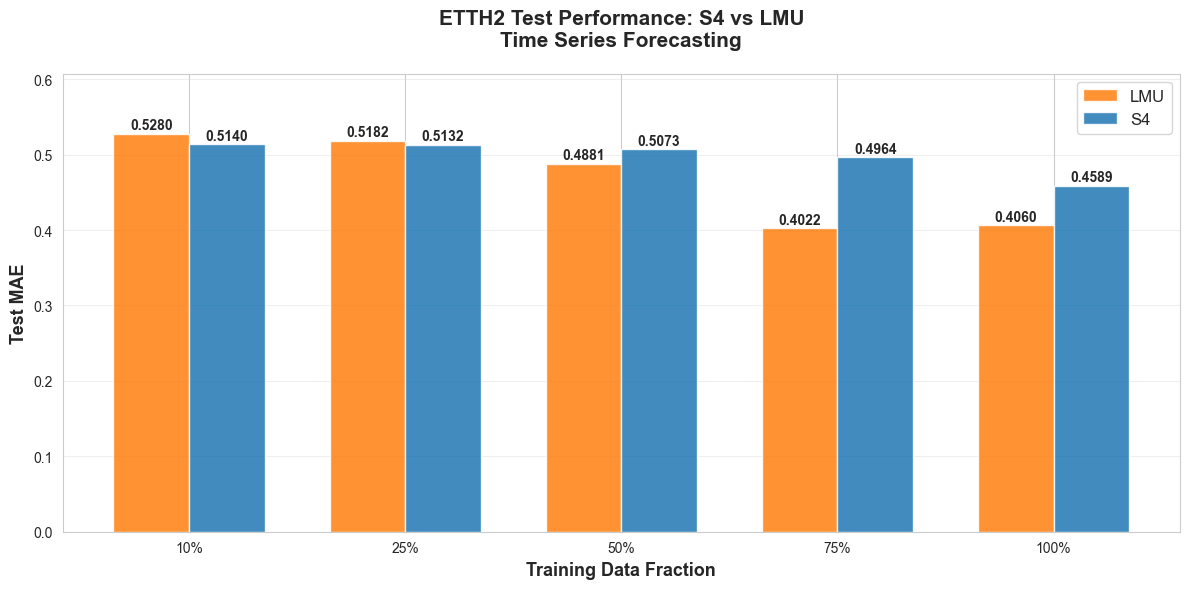

In [5]:
pivot_data = test_comparison_df.pivot(index='data_pct', columns='model', values='test_mae')

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(pivot_data.index))
width = 0.35

colors = {'S4': '#1f77b4', 'LMU': '#ff7f0e'}

for i, model in enumerate(pivot_data.columns):
    values = pivot_data[model].values
    offset = width * (i - 0.5)
    bars = ax.bar(x + offset, values, width,
                  label=model,
                  alpha=0.85,
                  color=colors.get(model, '#2ca02c'))

    # Add value labels on bars
    for j, (bar, val) in enumerate(zip(bars, values)):
        if not np.isnan(val):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                   f'{val:.4f}',
                   ha='center', va='bottom',
                   fontsize=10, fontweight='bold')

ax.set_xlabel('Training Data Fraction', fontsize=13, fontweight='bold')
ax.set_ylabel('Test MAE', fontsize=13, fontweight='bold')
ax.set_title(f'{dataset.upper()} Test Performance: S4 vs LMU\nTime Series Forecasting',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([f'{int(pct)}%' for pct in pivot_data.index])
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(pivot_data.max()) * 1.15)

plt.tight_layout()
plt.show()

---
## 5. Data Efficiency Analysis

Line plot showing how test performance scales with training data size.


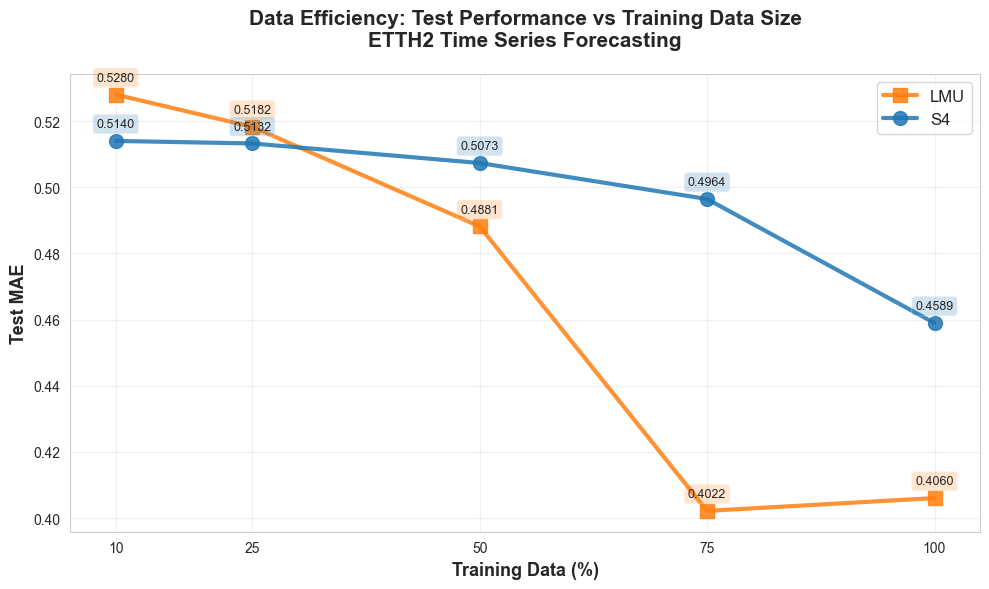

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'S4': '#1f77b4', 'LMU': '#ff7f0e'}
markers = {'S4': 'o', 'LMU': 's'}

for model in pivot_data.columns:
    data = pivot_data[model].dropna()
    ax.plot(data.index, data.values,
           label=model,
           marker=markers.get(model, 'o'),
           markersize=10,
           linewidth=3,
           color=colors.get(model, '#2ca02c'),
           alpha=0.85)

    # Add value annotations
    for pct, val in zip(data.index, data.values):
        ax.annotate(f'{val:.4f}',
                   xy=(pct, val),
                   xytext=(0, 10),
                   textcoords='offset points',
                   ha='center',
                   fontsize=9,
                   bbox=dict(boxstyle='round,pad=0.3',
                           facecolor=colors.get(model, '#2ca02c'),
                           alpha=0.2))

ax.set_xlabel('Training Data (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Test MAE', fontsize=13, fontweight='bold')
ax.set_title(f'Data Efficiency: Test Performance vs Training Data Size\n{dataset.upper()} Time Series Forecasting',
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xticks([10, 25, 50, 75, 100])
ax.set_xlim(5, 105)

plt.tight_layout()
plt.show()

---
## 8. Performance Heatmap

Heatmap showing test and val MAE across all model/fraction combinations.


Generating heatmap for etth1...


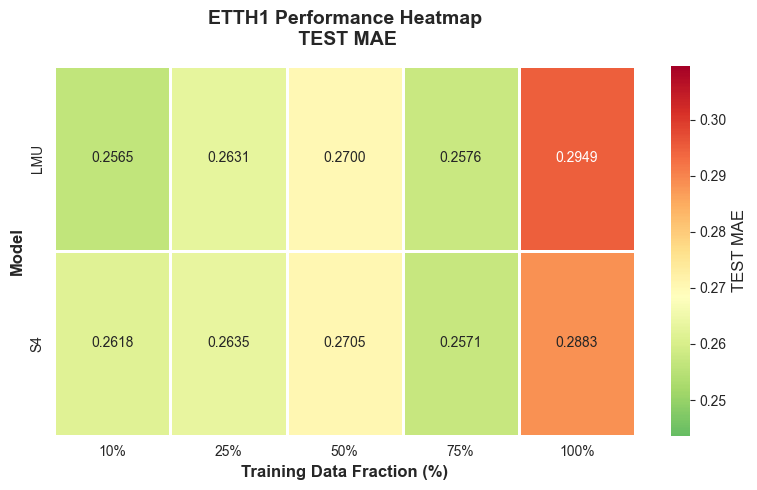

Generating heatmap for etth2...


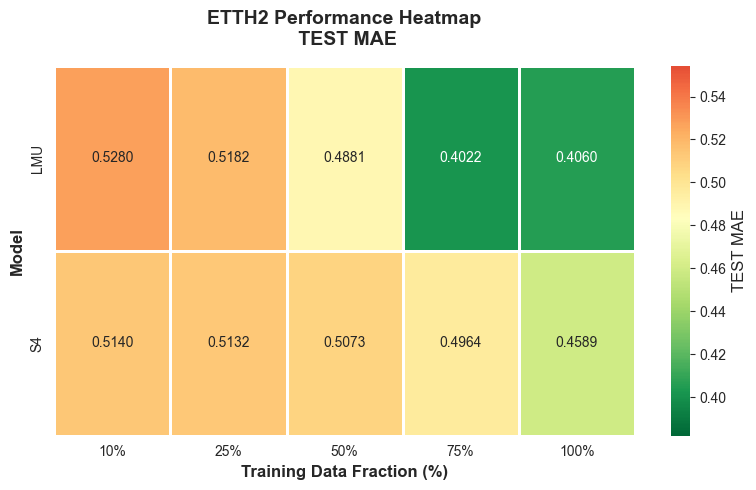

Generating heatmap for ettm1...


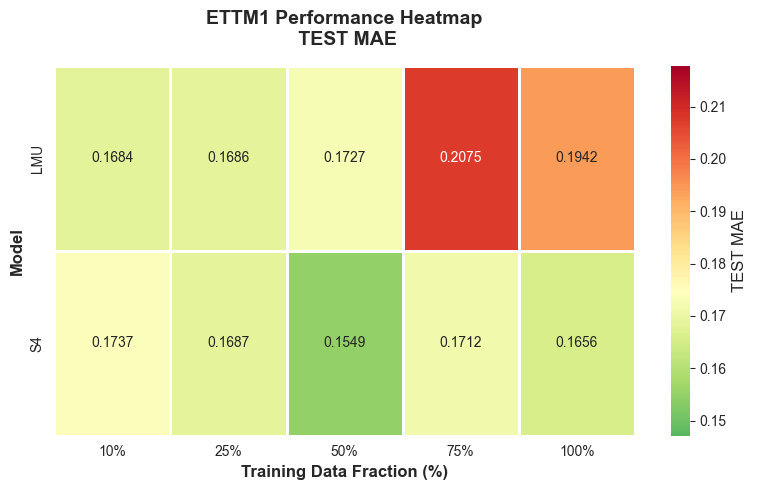

Generating heatmap for ettm2...


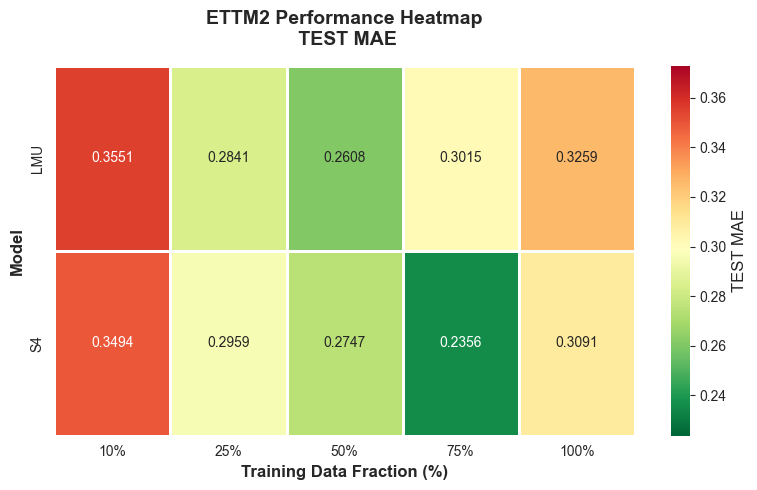

In [7]:
def create_heatmap(dataset: str, metric: str = 'test_mae'):
    metric_name = metric.replace('_', ' ').upper()
    fig, ax = plt.subplots(figsize=(8, 5))

    results = load_all_experiments(
        base_dir=base_dir,
        models=models,
        fractions=fractions,
        task_name="etts",
        sub_task=dataset,
        print_logs=False
    )

    comparison_df = create_test_comparison_table(
        results,
        metrics=[metric]
    )

    _pivot_data = comparison_df.pivot(index='data_pct', columns='model', values=metric)

    # Prepare data for heatmap
    _heatmap_data = _pivot_data.T

    # Create heatmap
    sns.heatmap(_heatmap_data,
                annot=True,
                fmt='.4f',
                cmap='RdYlGn_r',  # Reversed because lower MAE is better
                center=_heatmap_data.mean().mean(),
                cbar_kws={'label': metric_name},
                linewidths=1,
                linecolor='white',
                ax=ax,
                vmin=_heatmap_data.min().min() * 0.95,
                vmax=_heatmap_data.max().max() * 1.05)

    ax.set_xlabel('Training Data Fraction (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Model', fontsize=12, fontweight='bold')
    ax.set_title(f'{dataset.upper()} Performance Heatmap\n {metric_name}',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xticklabels([f'{int(float(x.get_text()))}%' for x in ax.get_xticklabels()])

    plt.tight_layout()
    plt.show()

datasets = ['etth1', 'etth2', 'ettm1', 'ettm2']

for ds in datasets:
    print(f"Generating heatmap for {ds}...")
    create_heatmap(ds)
    print("=" * 120)

#### Validation MAE Heatmaps

Generating heatmap for etth1...


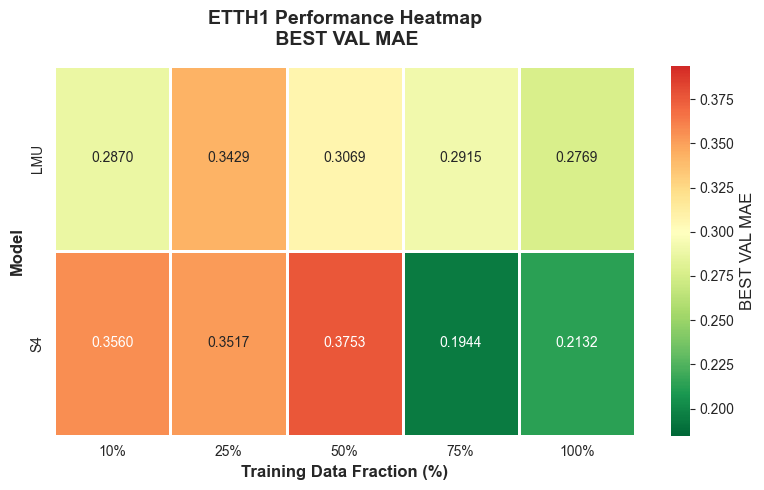

Generating heatmap for etth2...


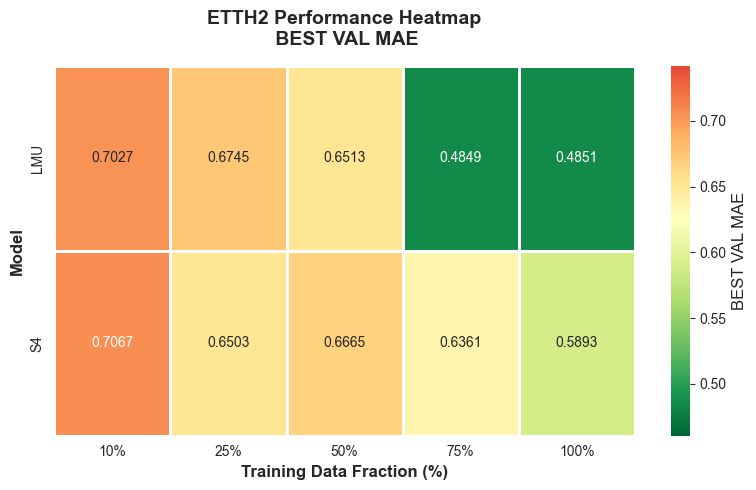

Generating heatmap for ettm1...


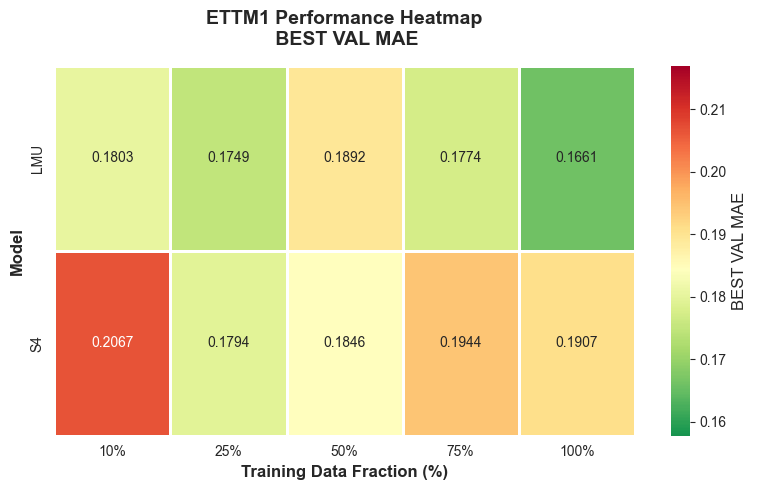

Generating heatmap for ettm2...


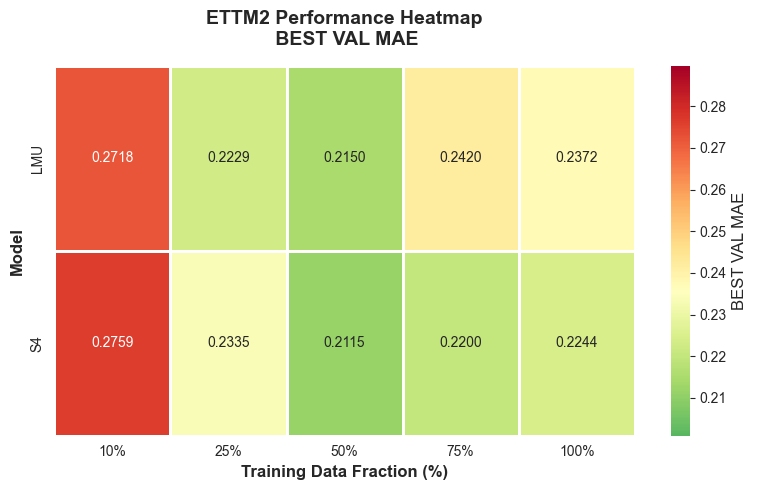

In [8]:
for ds in datasets:
    print(f"Generating heatmap for {ds}...")
    create_heatmap(ds, metric='best_val_mae')
    print("=" * 120)

---
## 9. Statistical Summary

Aggregate statistics across all experiments to assess model consistency and performance range.


In [9]:
print("=" * 70)
print(f"STATISTICAL SUMMARY - {dataset.upper()}")
print("=" * 70)
print()

for model in pivot_data.columns:
    model_data = pivot_data[model].dropna()

    print(f"{model}:")
    print(f"  Mean Test MAE:   {model_data.mean():.4f}")
    print(f"  Std Dev:         {model_data.std():.4f}")
    print(f"  Min Test MAE:    {model_data.min():.4f} (at {model_data.idxmin()}% data)")
    print(f"  Max Test MAE:    {model_data.max():.4f} (at {model_data.idxmax()}% data)")
    print(f"  Range:           {model_data.max() - model_data.min():.4f}")
    print()

print("=" * 70)

STATISTICAL SUMMARY - ETTH2

LMU:
  Mean Test MAE:   0.4685
  Std Dev:         0.0606
  Min Test MAE:    0.4022 (at 75% data)
  Max Test MAE:    0.5280 (at 10% data)
  Range:           0.1258

S4:
  Mean Test MAE:   0.4980
  Std Dev:         0.0229
  Min Test MAE:    0.4589 (at 100% data)
  Max Test MAE:    0.5140 (at 10% data)
  Range:           0.0550

